In [1]:
#sarinakasaiyan
import numpy as np
import random
from collections import defaultdict

# Define Gridworld parameters
grid_size = 4
terminal_states = [(0, 0), (3, 3)]
actions = ['up', 'down', 'left', 'right']
gamma = 1.0  # discount factor

# Step function
def step(state, action):
    i, j = state
    if state in terminal_states:
        return state, 0
    if action == 'up':
        i = max(i - 1, 0)
    elif action == 'down':
        i = min(i + 1, grid_size - 1)
    elif action == 'left':
        j = max(j - 1, 0)
    elif action == 'right':
        j = min(j + 1, grid_size - 1)
    next_state = (i, j)
    reward = 0 if next_state in terminal_states else -1
    return next_state, reward

# Generate an episode using a random policy
def generate_episode():
    state = random.choice([(i, j) for i in range(grid_size) for j in range(grid_size) if (i, j) not in terminal_states])
    episode = []
    while state not in terminal_states:
        action = random.choice(actions)
        next_state, reward = step(state, action)
        episode.append((state, action, reward))
        state = next_state
    return episode

# Monte Carlo Evaluation
def monte_carlo(num_episodes=1000):
    returns = defaultdict(list)
    V = defaultdict(float)

    for _ in range(num_episodes):
        episode = generate_episode()
        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            state, _, reward = episode[t]
            G = gamma * G + reward
            if state not in visited:
                returns[state].append(G)
                V[state] = np.mean(returns[state])
                visited.add(state)
    return V

# TD(0) Evaluation
def td_0(num_episodes=1000, alpha=0.1):
    V = defaultdict(float)

    for _ in range(num_episodes):
        state = random.choice([(i, j) for i in range(grid_size) for j in range(grid_size) if (i, j) not in terminal_states])
        while state not in terminal_states:
            action = random.choice(actions)
            next_state, reward = step(state, action)
            V[state] += alpha * (reward + gamma * V[next_state] - V[state])
            state = next_state
    return V

# Run both methods
mc_values = monte_carlo()
td_values = td_0()

# Print some example values
for i in range(grid_size):
    for j in range(grid_size):
        print(f"({i},{j}): MC={mc_values.get((i,j), 0):6.2f} | TD={td_values.get((i,j), 0):6.2f}")


(0,0): MC=  0.00 | TD=  0.00
(0,1): MC= -6.74 | TD=-11.58
(0,2): MC= -8.82 | TD=-18.26
(0,3): MC=-10.88 | TD=-19.87
(1,0): MC= -6.65 | TD= -8.56
(1,1): MC= -7.49 | TD=-17.02
(1,2): MC= -8.30 | TD=-18.35
(1,3): MC= -8.87 | TD=-18.73
(2,0): MC= -9.59 | TD=-18.45
(2,1): MC= -8.26 | TD=-19.23
(2,2): MC= -7.71 | TD=-15.90
(2,3): MC= -6.54 | TD=-12.54
(3,0): MC=-11.61 | TD=-21.64
(3,1): MC= -8.99 | TD=-19.33
(3,2): MC= -6.52 | TD=-13.04
(3,3): MC=  0.00 | TD=  0.00


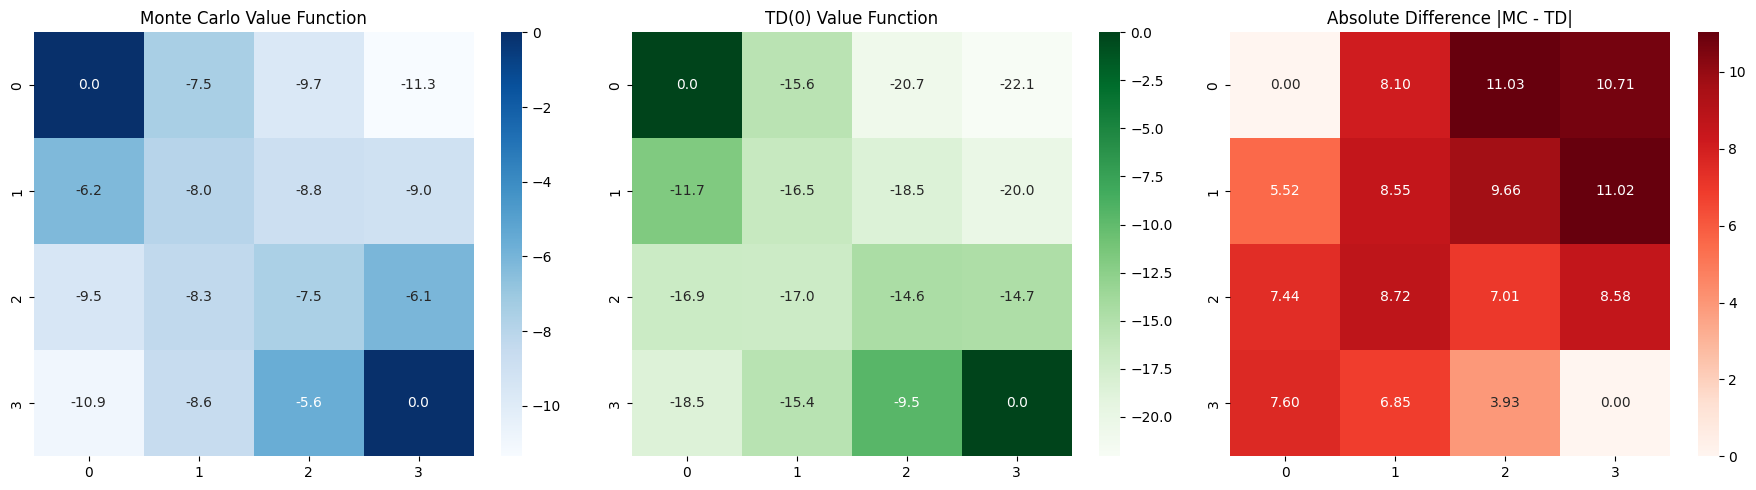

State  Monte Carlo  TD(0)  Abs Diff
(0,0)         0.00   0.00      0.00
(0,1)        -7.46 -15.57      8.10
(0,2)        -9.67 -20.70     11.03
(0,3)       -11.35 -22.06     10.71
(1,0)        -6.23 -11.75      5.52
(1,1)        -7.95 -16.50      8.55
(1,2)        -8.85 -18.51      9.66
(1,3)        -9.02 -20.04     11.02
(2,0)        -9.50 -16.95      7.44
(2,1)        -8.32 -17.04      8.72
(2,2)        -7.55 -14.56      7.01
(2,3)        -6.08 -14.67      8.58
(3,0)       -10.93 -18.53      7.60
(3,1)        -8.59 -15.44      6.85
(3,2)        -5.60  -9.53      3.93
(3,3)         0.00   0.00      0.00


In [2]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gridworld settings
grid_size = 4
terminal_states = [(0, 0), (3, 3)]
actions = ['up', 'down', 'left', 'right']
gamma = 1.0  # Discount factor

# Environment step function
def step(state, action):
    i, j = state
    if state in terminal_states:
        return state, 0
    if action == 'up':
        i = max(i - 1, 0)
    elif action == 'down':
        i = min(i + 1, grid_size - 1)
    elif action == 'left':
        j = max(j - 1, 0)
    elif action == 'right':
        j = min(j + 1, grid_size - 1)
    next_state = (i, j)
    reward = 0 if next_state in terminal_states else -1
    return next_state, reward

# Generate an episode with random policy
def generate_episode():
    state = random.choice([(i, j) for i in range(grid_size) for j in range(grid_size) if (i, j) not in terminal_states])
    episode = []
    while state not in terminal_states:
        action = random.choice(actions)
        next_state, reward = step(state, action)
        episode.append((state, action, reward))
        state = next_state
    return episode

# Monte Carlo value estimation
def monte_carlo(num_episodes=1000):
    returns = defaultdict(list)
    V = defaultdict(float)

    for _ in range(num_episodes):
        episode = generate_episode()
        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            state, _, reward = episode[t]
            G = gamma * G + reward
            if state not in visited:
                returns[state].append(G)
                V[state] = np.mean(returns[state])
                visited.add(state)
    return V

# TD(0) value estimation
def td_0(num_episodes=1000, alpha=0.1):
    V = defaultdict(float)

    for _ in range(num_episodes):
        state = random.choice([(i, j) for i in range(grid_size) for j in range(grid_size) if (i, j) not in terminal_states])
        while state not in terminal_states:
            action = random.choice(actions)
            next_state, reward = step(state, action)
            V[state] += alpha * (reward + gamma * V[next_state] - V[state])
            state = next_state
    return V

# Run both algorithms
mc_values = monte_carlo()
td_values = td_0()

# Create value grids
mc_grid = np.zeros((grid_size, grid_size))
td_grid = np.zeros((grid_size, grid_size))
diff_grid = np.zeros((grid_size, grid_size))

for i in range(grid_size):
    for j in range(grid_size):
        mc_v = mc_values.get((i, j), 0)
        td_v = td_values.get((i, j), 0)
        mc_grid[i, j] = mc_v
        td_grid[i, j] = td_v
        diff_grid[i, j] = abs(mc_v - td_v)

# 📊 Heatmap plots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(mc_grid, annot=True, fmt=".1f", cmap="Blues", ax=axs[0])
axs[0].set_title("Monte Carlo Value Function")

sns.heatmap(td_grid, annot=True, fmt=".1f", cmap="Greens", ax=axs[1])
axs[1].set_title("TD(0) Value Function")

sns.heatmap(diff_grid, annot=True, fmt=".2f", cmap="Reds", ax=axs[2])
axs[2].set_title("Absolute Difference |MC - TD|")

plt.tight_layout()
plt.show()

# 📋 Tabular comparison
comparison_data = []
for i in range(grid_size):
    for j in range(grid_size):
        pos = f"({i},{j})"
        mc = mc_values.get((i, j), 0)
        td = td_values.get((i, j), 0)
        diff = abs(mc - td)
        comparison_data.append([pos, round(mc, 2), round(td, 2), round(diff, 2)])

df = pd.DataFrame(comparison_data, columns=["State", "Monte Carlo", "TD(0)", "Abs Diff"])
print(df.to_string(index=False))
